In [1]:
#Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_PATH = Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
# Load and quick look
df = pd.read_csv(DATA_PATH)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(subset=["TotalCharges"], inplace=True)
df["Churn"] = (df["Churn"] == "Yes").astype(int)
df.drop(columns=["customerID"], inplace=True)

print(df.shape)
df.head()

(7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [5]:
# Data Types and Nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

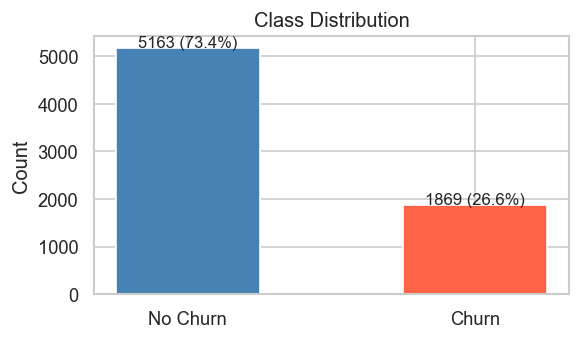

In [7]:
# Class Imbalance
fig, ax = plt.subplots(figsize=(5, 3))
counts = df["Churn"].value_counts()
ax.bar(["No Churn", "Churn"], counts, color=["steelblue", "tomato"], width=0.5)
for i, v in enumerate(counts):
    ax.text(i, v + 30, f"{v} ({v/len(df):.1%})", ha="center", fontsize=10)
ax.set_title("Class Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

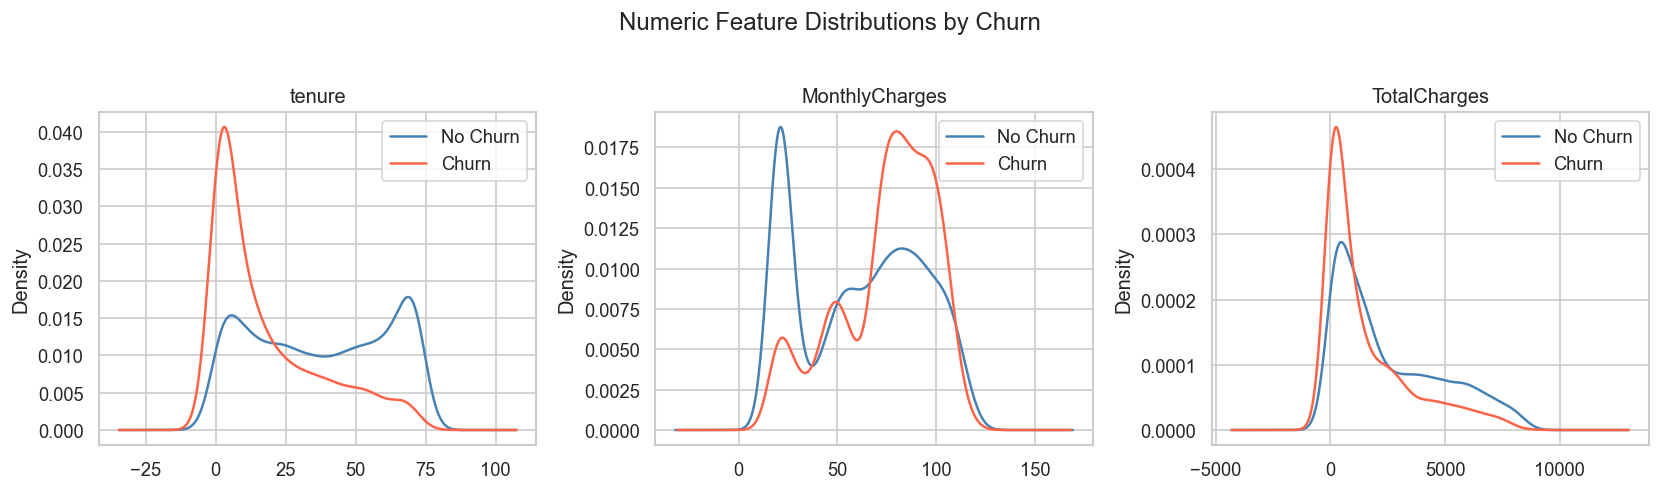

In [9]:
# Numeric distributions by churn
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, numeric_cols):
    df[df["Churn"] == 0][col].plot.kde(ax=ax, label="No Churn", color="steelblue")
    df[df["Churn"] == 1][col].plot.kde(ax=ax, label="Churn",    color="tomato")
    ax.set_title(col)
    ax.legend()
plt.suptitle("Numeric Feature Distributions by Churn", y=1.02)
plt.tight_layout()
plt.show()

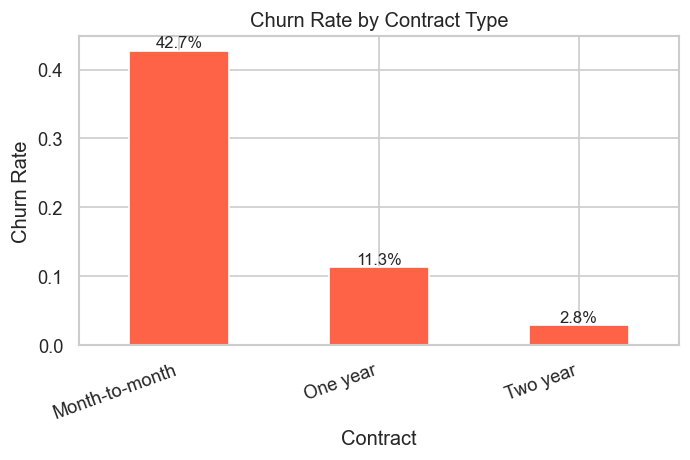

In [11]:
# Churn rate by contract type
fig, ax = plt.subplots(figsize=(6, 4))
contract_churn = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
contract_churn.plot.bar(ax=ax, color="tomato", width=0.5)
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("Churn Rate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
for i, v in enumerate(contract_churn):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

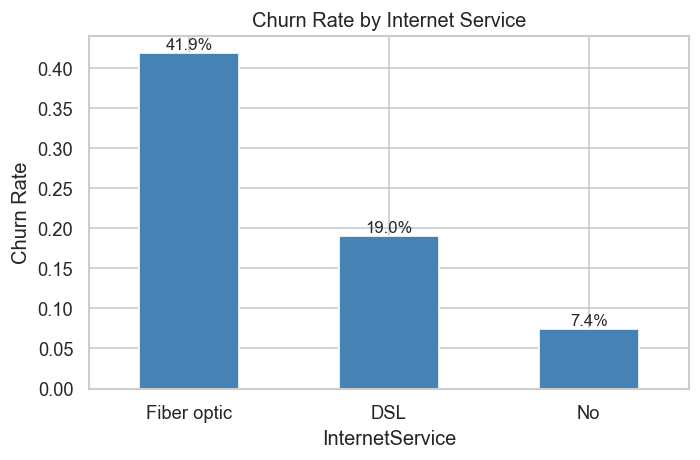

In [13]:
# Churn rate by internet service
fig, ax = plt.subplots(figsize=(6, 4))
internet_churn = df.groupby("InternetService")["Churn"].mean().sort_values(ascending=False)
internet_churn.plot.bar(ax=ax, color="steelblue", width=0.5)
ax.set_title("Churn Rate by Internet Service")
ax.set_ylabel("Churn Rate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(internet_churn):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

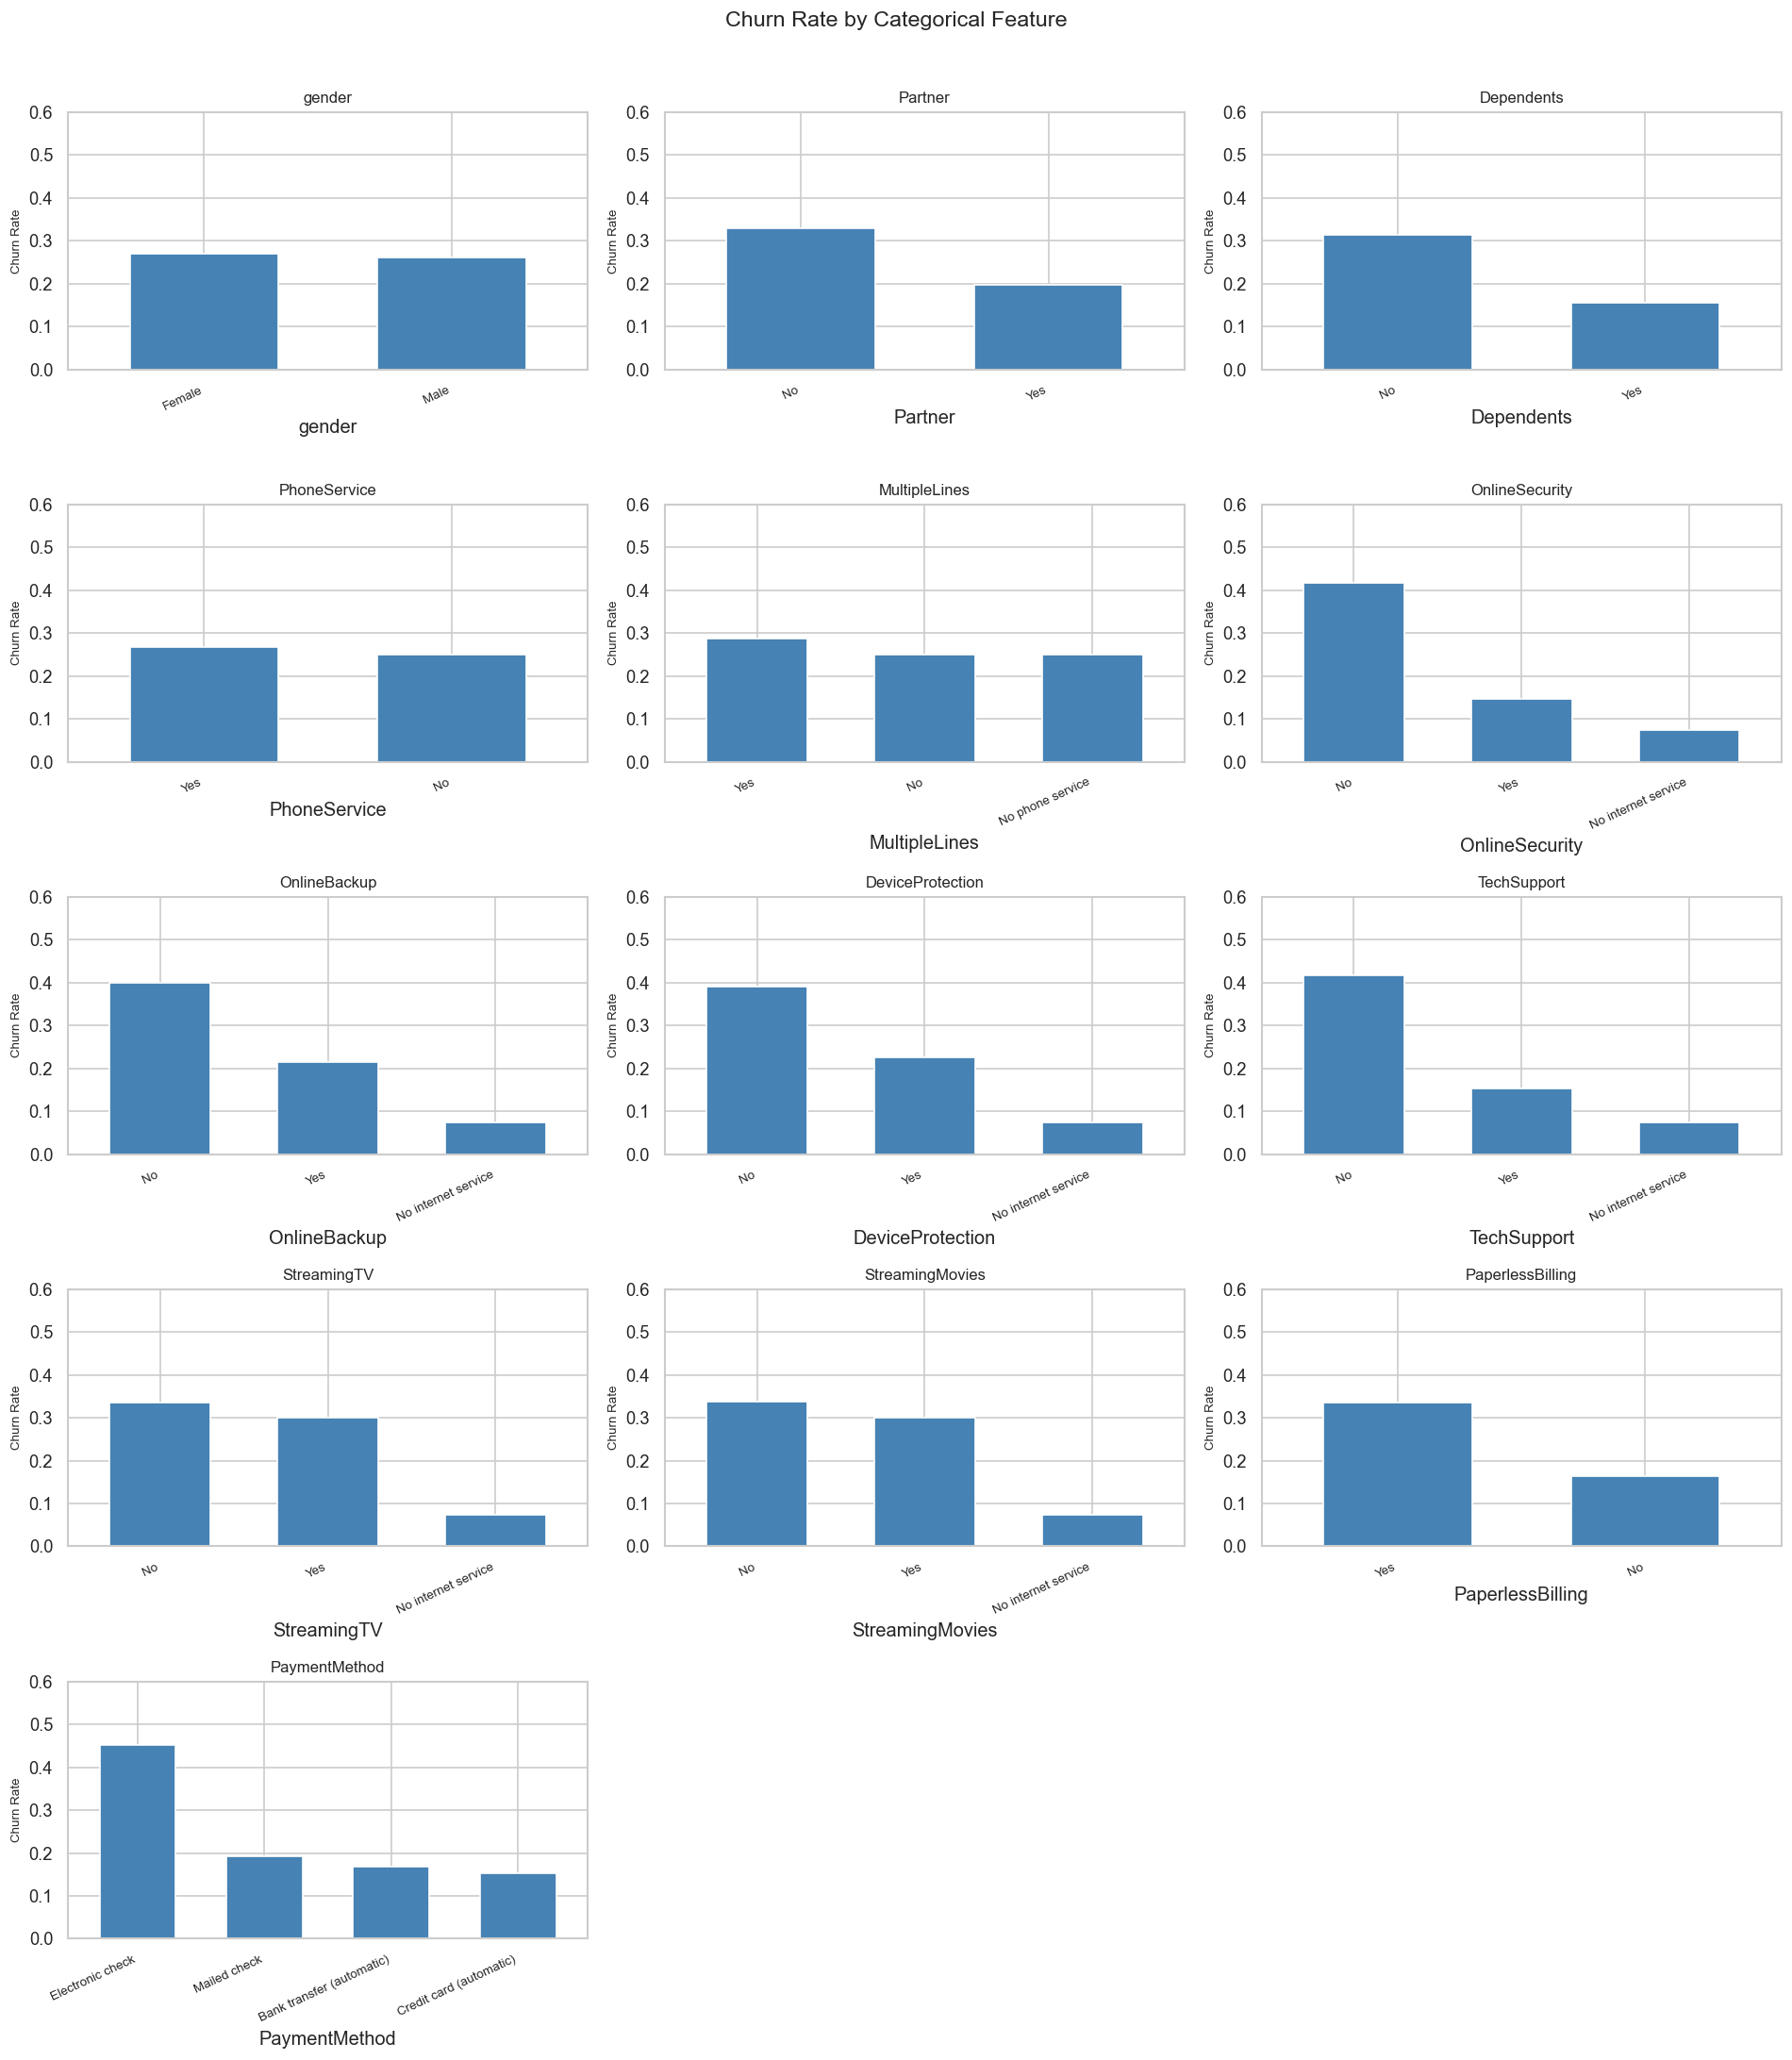

In [15]:
# Churn rate across all categorical features
categorical_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "PaperlessBilling", "PaymentMethod",
]

fig, axes = plt.subplots(5, 3, figsize=(16, 18))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    churn_rate.plot.bar(ax=ax, color="steelblue", width=0.6)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Churn Rate", fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, 0.6)

for ax in axes[len(categorical_cols):]:
    ax.set_visible(False)

plt.suptitle("Churn Rate by Categorical Feature", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

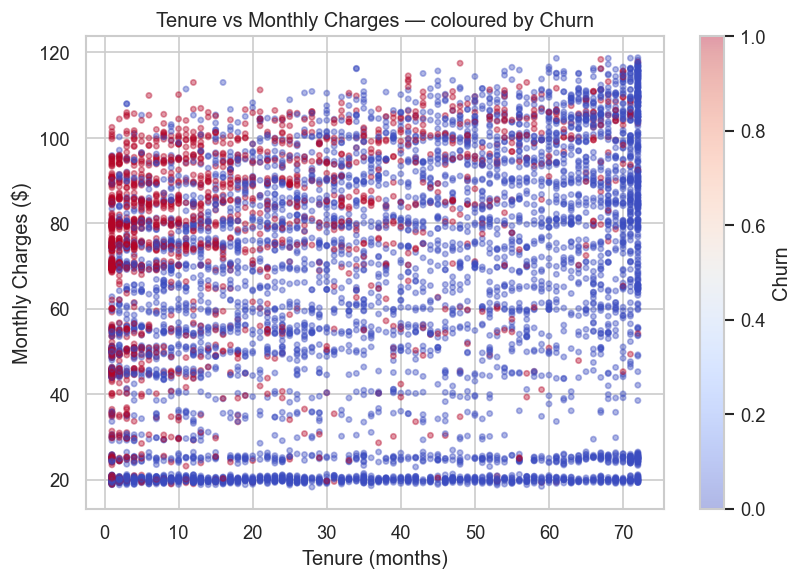

In [17]:
# Tenure vs monthly charges scatter coloured by churn
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    df["tenure"], df["MonthlyCharges"],
    c=df["Churn"], cmap="coolwarm", alpha=0.4, s=10,
)
plt.colorbar(scatter, ax=ax, label="Churn")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Monthly Charges ($)")
ax.set_title("Tenure vs Monthly Charges — coloured by Churn")
plt.tight_layout()
plt.show()

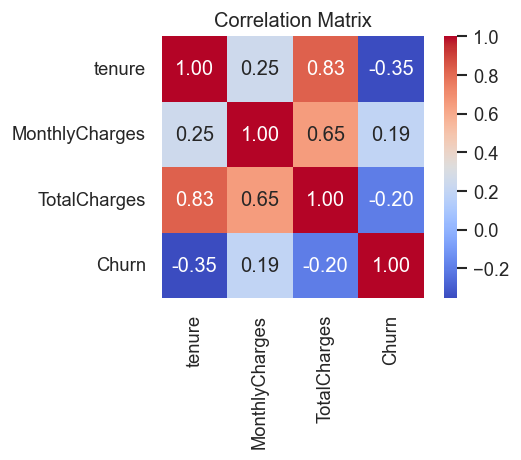

In [19]:
# Correlation heatmap (numeric only)
fig, ax = plt.subplots(figsize=(5, 4))
corr = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, square=True)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()